# Introduction to Data Analysis and Modeling with Python

In this notebook, we will learn the first steps that data scientists and machine learning engineers use when working with numerical data.

We will practice:

- Loading a dataset
- Inspecting the data
- Cleaning missing values
- Using NumPy and Pandas
- Visualizing data
- Finding correlations
- Filtering data
- Fitting simple models
- Evaluating model performance
- Making predictions

By the end, you should understand the basic workflow used before building machine learning models.

We use:

- `pandas` to load and organize data
- `numpy` for numerical calculations
- `matplotlib` for plotting

In [1]:
# Although there are some exceptions, it is generally a good idea to keep all of your
# imports in one place so that you can easily manage them. Doing so also makes it easy
# to copy all of them at once and paste them into a new notebook you are starting.

import numpy as np # NumPy is a library for working with arrays and performing mathematical operations on them.
import pandas as pd # Pandas is a library for working with data in tabular form, such as data frames.
import matplotlib.pyplot as plt # Matplotlib is a library for creating visualizations, such as plots and charts.

## 1. Loading the Dataset

The first step in any data analysis project is loading the data.

Our dataset contains yearly GDP values for different countries.

If you open the CSV file, you will notice that the first 4 rows contain extra information that is not part of the actual data table. Because of this, we use `skiprows=4`.

In [2]:
gdp = pd.read_csv("GDP_Data.csv", delimiter=",", skiprows=4) # Make sure the csv file and notebook are in the same folder, or provide the full path to the csv file.

gdp.head() # The head() method is used to display the first few rows of a DataFrame. By default, it shows the first 5 rows, but you can specify a different number by passing an argument to the method (e.g., gdp.head(10) to show the first 10 rows).

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Unnamed: 67
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.791061e+09,2.963128e+09,2.983799e+09,3.092179e+09,3.276188e+09,3.395794e+09,2.610039e+09,3.126019e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,...,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,...,2.055058e+10,1.999814e+10,1.801955e+10,1.889635e+10,1.841886e+10,1.890450e+10,2.014345e+10,1.458314e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,...,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.372444e+11,8.721930e+10,4.984049e+10,6.897277e+10,7.779294e+10,6.930911e+10,5.024137e+10,6.568544e+10,1.067136e+11,NaN


`head()` shows the first few rows of the dataset. This helps us check that the file loaded correctly.

## 2. First Look at the Data

Before doing any analysis, we should understand what kind of data we have.

Important questions:

- How many rows and columns are there?
- What are the column names?
- Which columns are numerical?
- Are there missing values?
- What are the minimum, maximum, mean, and standard deviation?

In [3]:
gdp.shape # Shows the number of rows and columns in the DataFrame

(266, 68)

In [4]:
gdp.columns # Shows the column names in the DataFrame

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       'Unnamed: 67'],
      dtype='str')

In [5]:
gdp.info() # The info() method provides a concise summary of the DataFrame, including the number of non-null entries, data types of each column, and memory usage. 

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            132 non-null    float64
 5   1961            134 non-null    float64
 6   1962            136 non-null    float64
 7   1963            136 non-null    float64
 8   1964            136 non-null    float64
 9   1965            147 non-null    float64
 10  1966            150 non-null    float64
 11  1967            153 non-null    float64
 12  1968            158 non-null    float64
 13  1969            158 non-null    float64
 14  1970            167 non-null    float64
 15  1971            170 non-null    float64
 16  1972            170 non-null    float64
 17  1973            170 non-null    float64
 18  1

## 3. Finding Missing Values

Real-world datasets often contain missing values.

In Python, missing numerical values usually appear as `NaN`, which means “Not a Number.”

Before cleaning the data, we should check where those missing values are.

In [6]:
gdp.isna().sum() # The isna() method returns a DataFrame of the same shape as the original, with True for entries that are NaN (missing) and False for entries that are not

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              134
                 ... 
2019                9
2020                9
2021               15
2022               33
Unnamed: 67       266
Length: 68, dtype: int64

The dataset also contains a fully empty column at the end called something like `Unnamed: 67`.

If we use `dropna()` immediately, Python will remove every row because every row has a missing value in that empty column.

So we first remove fully empty and unnecessary columns, then remove rows that still contain missing values.

In [7]:
# Drop columns that are completely empty
gdp_clean = gdp.dropna(axis="columns", how="all")

# Remove unnecessary columns
gdp_clean = gdp_clean.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])

# Drop rows that still contain missing values
gdp_clean = gdp_clean.dropna()

# Check result
gdp_clean.head()

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
1,Africa Eastern and Southern,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,3.201437e+10,3.326951e+10,3.632779e+10,...,9.859871e+11,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12
3,Africa Western and Central,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,1.591084e+10,1.451058e+10,1.496824e+10,...,8.339481e+11,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11
13,Australia,1.860656e+10,1.968288e+10,1.992256e+10,2.153984e+10,2.380112e+10,2.597616e+10,2.730784e+10,3.044272e+10,3.271409e+10,...,1.576330e+12,1.467590e+12,1.350580e+12,1.206563e+12,1.326467e+12,1.428267e+12,1.392219e+12,1.326945e+12,1.552703e+12,1.675419e+12
14,Austria,6.592694e+09,7.311750e+09,7.756110e+09,8.374175e+09,9.169984e+09,9.994071e+09,1.088768e+10,1.157943e+10,1.244063e+10,...,4.301910e+11,4.425848e+11,3.819711e+11,3.958374e+11,4.172612e+11,4.549912e+11,4.446212e+11,4.352252e+11,4.803684e+11,4.714001e+11
16,Burundi,1.960000e+08,2.030000e+08,2.135000e+08,2.327500e+08,2.607500e+08,1.589950e+08,1.654446e+08,1.782971e+08,1.832000e+08,...,2.451607e+09,2.705783e+09,3.104004e+09,2.644488e+09,2.723587e+09,2.667182e+09,2.576519e+09,2.649680e+09,2.775799e+09,3.073415e+09


In [8]:
gdp_clean.shape

(122, 64)

In [9]:
gdp_clean.isna().sum()

Country Name    0
1960            0
1961            0
1962            0
1963            0
               ..
2018            0
2019            0
2020            0
2021            0
2022            0
Length: 64, dtype: int64

### Transposing the Dataset

Now that our dataset only contains:
- Country Name
- GDP values by year

We can transpose the data to better analyze trends over time.

After transposing:
- Rows → Years  
- Columns → Countries

In [10]:
# Transpose the dataset
gdp_transposed = gdp_clean.set_index("Country Name").T # Transpose the dataset and set "Country Name" as the index

# Convert index (years) to integers
gdp_transposed.index = gdp_transposed.index.astype(int) # Convert the index to integers so that it can be used for plotting and analysis

# Check result
gdp_transposed.head()

Country Name,Africa Eastern and Southern,Africa Western and Central,Australia,Austria,Burundi,Belgium,Benin,Burkina Faso,Bangladesh,"Bahamas, The",...,Turkiye,Uganda,Upper middle income,Uruguay,United States,St. Vincent and the Grenadines,World,South Africa,Zambia,Zimbabwe
1960,2.112502e+10,1.044764e+10,1.860656e+10,6.592694e+09,1.960000e+08,1.165872e+10,2.261956e+08,3.304428e+08,4.274894e+09,1.698039e+08,...,7.552471e+09,4.230084e+08,2.293135e+11,1.242289e+09,5.433000e+11,1.306663e+07,1.384857e+12,8.748597e+09,7.130000e+08,1.052990e+09
1961,2.161623e+10,1.117321e+10,1.968288e+10,7.311750e+09,2.030000e+08,1.240015e+10,2.356682e+08,3.502472e+08,4.817580e+09,1.900980e+08,...,7.971175e+09,4.415241e+08,2.175573e+11,1.547389e+09,5.633000e+11,1.399996e+07,1.449221e+12,9.225996e+09,6.962857e+08,1.096647e+09
1962,2.350628e+10,1.199053e+10,1.992256e+10,7.756110e+09,2.135000e+08,1.326402e+10,2.364350e+08,3.795671e+08,5.081413e+09,2.122549e+08,...,8.902439e+09,4.490126e+08,2.231230e+11,1.710004e+09,6.051000e+11,1.452496e+07,1.550815e+12,9.813996e+09,6.931429e+08,1.117602e+09
1963,2.804836e+10,1.272769e+10,2.153984e+10,8.374175e+09,2.327500e+08,1.426002e+10,2.539277e+08,3.940407e+08,5.319458e+09,2.377451e+08,...,1.033259e+10,5.161478e+08,2.341295e+11,1.539681e+09,6.386000e+11,1.370830e+07,1.671447e+12,1.085420e+10,7.187143e+08,1.159512e+09
1964,2.592067e+10,1.389811e+10,2.380112e+10,9.169984e+09,2.607500e+08,1.596011e+10,2.698190e+08,4.103216e+08,5.386055e+09,2.666667e+08,...,1.112934e+10,5.890566e+08,2.686610e+11,1.975702e+09,6.858000e+11,1.475830e+07,1.830492e+12,1.195600e+10,8.394286e+08,1.217138e+09


## 4. Basic Statistics

Now that the data has been cleaned, we can calculate basic statistics.

In [11]:
gdp_transposed.describe() # The describe() method generates descriptive statistics of the DataFrame, such as count, mean, standard deviation, minimum, and maximum values for each column. 

Country Name,Africa Eastern and Southern,Africa Western and Central,Australia,Austria,Burundi,Belgium,Benin,Burkina Faso,Bangladesh,"Bahamas, The",...,Turkiye,Uganda,Upper middle income,Uruguay,United States,St. Vincent and the Grenadines,World,South Africa,Zambia,Zimbabwe
count,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,...,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01
mean,3.667304e+11,2.583643e+11,5.021923e+11,1.921223e+11,1.143043e+09,2.364756e+11,4.467904e+09,4.921643e+09,7.722066e+10,5.042234e+09,...,2.971710e+11,1.021024e+10,6.890874e+12,2.032258e+10,8.213796e+12,3.418689e+08,3.236618e+13,1.662057e+11,8.035328e+09,8.333485e+09
std,3.576800e+11,2.882058e+11,5.242522e+11,1.618063e+11,8.546859e+08,1.922357e+11,5.149336e+09,5.502421e+09,1.096384e+11,4.536228e+09,...,3.283127e+11,1.252553e+10,8.625467e+12,2.144360e+10,7.039549e+12,3.146269e+08,3.007489e+13,1.429850e+11,8.957124e+09,7.114212e+09
min,2.112502e+10,1.044764e+10,1.860656e+10,6.592694e+09,1.589950e+08,1.165872e+10,2.261956e+08,3.304428e+08,4.274894e+09,1.698039e+08,...,7.552471e+09,4.230084e+08,2.175573e+11,1.242289e+09,5.433000e+11,1.306663e+07,1.384857e+12,8.748597e+09,6.931429e+08,1.052990e+09
25%,9.052409e+10,5.700941e+10,1.011825e+11,4.150959e+10,4.346997e+08,6.839604e+10,6.876392e+08,9.582599e+08,1.131479e+10,6.565000e+08,...,4.795666e+10,1.900381e+09,9.892594e+11,4.027253e+09,1.779158e+12,3.308046e+07,6.238359e+12,4.214805e+10,2.349753e+09,4.334986e+09
50%,2.429264e+11,1.188931e+11,3.121381e+11,1.737942e+11,9.690467e+08,2.105110e+11,1.695315e+09,2.586551e+09,3.159834e+10,3.109000e+09,...,1.506762e+11,4.304399e+09,2.756767e+12,1.120617e+10,6.158129e+12,2.548296e+08,2.383445e+13,1.290876e+11,3.597221e+09,6.563813e+09
75%,6.202275e+11,4.312033e+11,8.011673e+11,3.591256e+11,1.314787e+09,4.352977e+11,7.601580e+09,7.086571e+09,7.571549e+10,9.909080e+09,...,6.031827e+11,1.094011e+10,9.618979e+12,2.468492e+10,1.414491e+13,6.785489e+08,5.507610e+13,3.099950e+11,1.340691e+10,8.597314e+09
max,1.169484e+12,8.943225e+11,1.675419e+12,4.803684e+11,3.104004e+09,5.943520e+11,1.769008e+10,1.973762e+10,4.602010e+11,1.305870e+10,...,9.577990e+11,4.555920e+10,3.005534e+13,7.117715e+10,2.546270e+13,9.485585e+08,1.005620e+14,4.581995e+11,2.978445e+10,3.415607e+10


Or use .describe() for a specific country.

In [12]:
country = "Australia"

gdp_transposed[country].describe()

count    6.300000e+01
mean     5.021923e+11
std      5.242522e+11
min      1.860656e+10
25%      1.011825e+11
50%      3.121381e+11
75%      8.011673e+11
max      1.675419e+12
Name: Australia, dtype: float64

Another way to calculate basic statistics is using numpy (np).

In [13]:
gdp_Australia = gdp_transposed[country]

print("Mean GDP:", np.mean(gdp_Australia)) 
print("Median GDP:", np.median(gdp_Australia))
print("Standard deviation:", np.std(gdp_Australia))


Mean GDP: 502192267619.7413
Median GDP: 312138139404.16
Standard deviation: 520074780773.7912


The mean gives the average value.

The median gives the middle value.

The standard deviation tells us how spread out the values are.

## 5. Visualizing One Variable

Here, we will look at how GDP values for a single country are distributed over time.

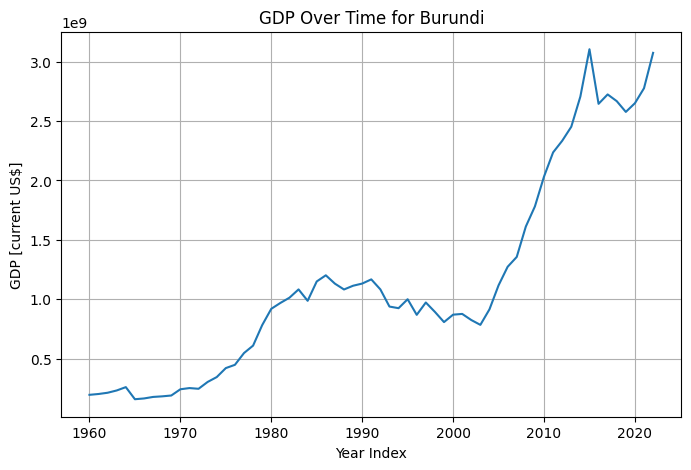

In [24]:
country = "Burundi"  # or any country you want

gdp_country = gdp_transposed[country] # Extract the GDP data for the specified country from the transposed DataFrame

plt.figure(figsize=(8,5)) # Create a new figure with a specified size (width=8 inches, height=5 inches) for better visualization of the plot
plt.plot(gdp_country) # Plot the GDP data for the specified country. x-axis is not explicitly specified, so it will default to the index of the DataFrame, which represents the years, and the y-axis will be the GDP values for that country. 
plt.xlabel("Year Index") # Set the label for the x-axis to "Year Index". This indicates that the x-axis represents the years corresponding to the GDP data.
plt.ylabel("GDP [current US$]") # Set the label for the y-axis to "GDP [current US$]". This indicates that the y-axis represents the GDP values in current US dollars.
plt.title(f"GDP Over Time for {country}") # Set the title for the plot to "GDP Over Time for [Country]".

plt.grid(True) # Add a grid to the plot for better readability.
plt.show() # Display the plot. 

## 6. Filtering Data with Masks

Sometimes we only want to look at specific parts of our data.

In Python, we can use **masks** (boolean conditions) to filter data.

For example, we might want to:
- Look at years where GDP is above a certain value
- Focus on periods of rapid growth

Japan, for exmaple, shows relatively consistent growth up to around 1995, as shown below.

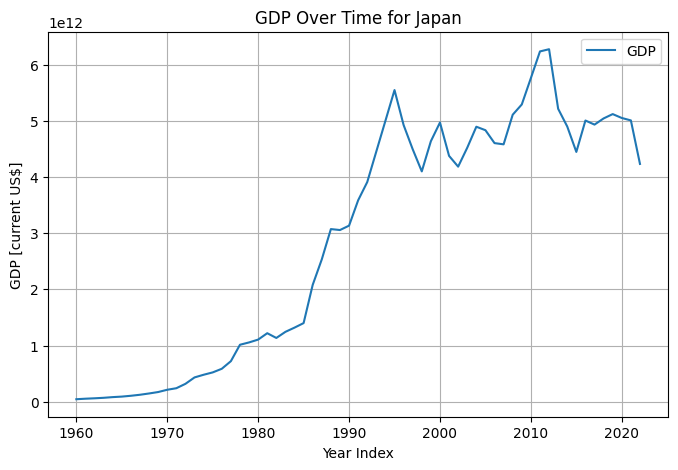

In [25]:
country = "Japan"
gdp_japan = gdp_transposed[country]

plt.figure(figsize=(8,5))
plt.plot(gdp_japan, label="GDP")

plt.xlabel("Year Index")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Over Time for {country}")

plt.legend()
plt.grid(True)
plt.show()

Using a mask, we can isolate specific time periods in the data.

This allows us to focus on particular trends without removing the rest of the dataset.

In [26]:
# Create mask for years before 1995
mask = gdp_japan.index < 1995 # Create a boolean mask that is True for years before 1995 and False for years 1995 and later.

gdp_before_1995 = gdp_japan[mask] # Use the mask to filter the GDP data for years before 1995.

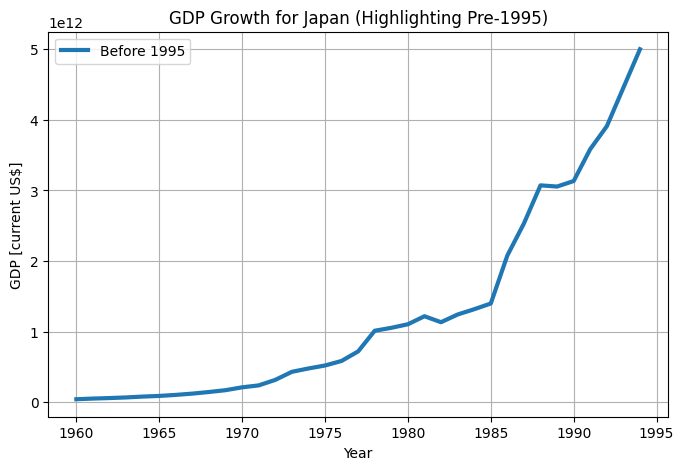

In [27]:
plt.figure(figsize=(8,5))

#plt.plot(gdp_japan, label="All data")
plt.plot(gdp_before_1995, label="Before 1995", linewidth=3)

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Growth for {country} (Highlighting Pre-1995)")

plt.legend()
plt.grid(True)
plt.show()

## 7. Comparing Multiple Countries

Now we will compare GDP over time for several countries.

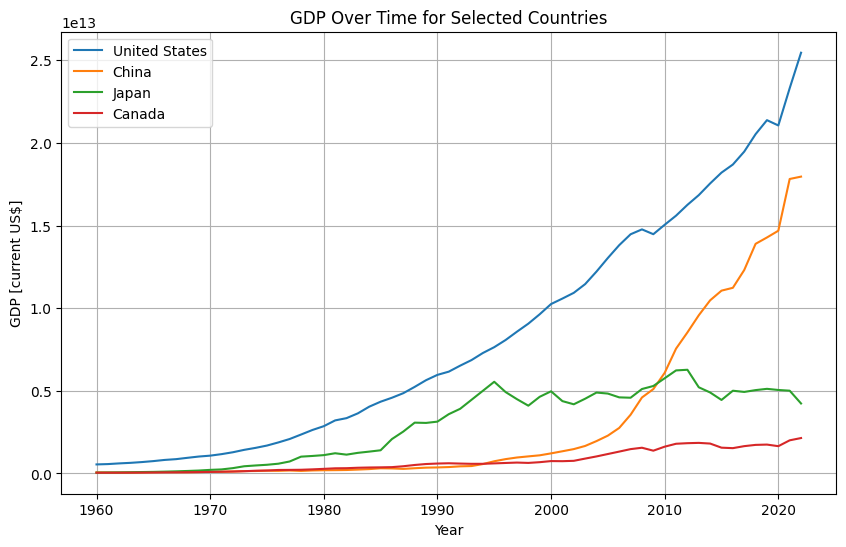

In [28]:
countries = ["United States", "China", "Japan", "Canada"] # Create a list of countries that we want to plot.

years = gdp_transposed.index.astype(int) # Convert the index to integers so that it can be used for plotting and analysis. This will allow us to plot the GDP data against the actual years on the x-axis.

plt.figure(figsize=(10, 6))

for country in countries: # Loop through each country in the list of countries to plot their GDP data on the same graph for comparison.
    if country not in gdp_transposed.columns: # Check if the country is present in the columns of the transposed DataFrame. If not, print a warning message and skip to the next country in the loop.
        print(f"Warning: {country} not found in dataset")
        continue

    gdp_values = gdp_transposed[country].values.astype(float) # Extract the GDP values for the current country and convert them to floats for plotting. 
    plt.plot(years, gdp_values, label=country) # Plot the GDP values for the current country against the years. 

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title("GDP Over Time for Selected Countries")

plt.legend()
plt.grid(True)
plt.show()

When values are very different in size, a log scale can make comparison easier.

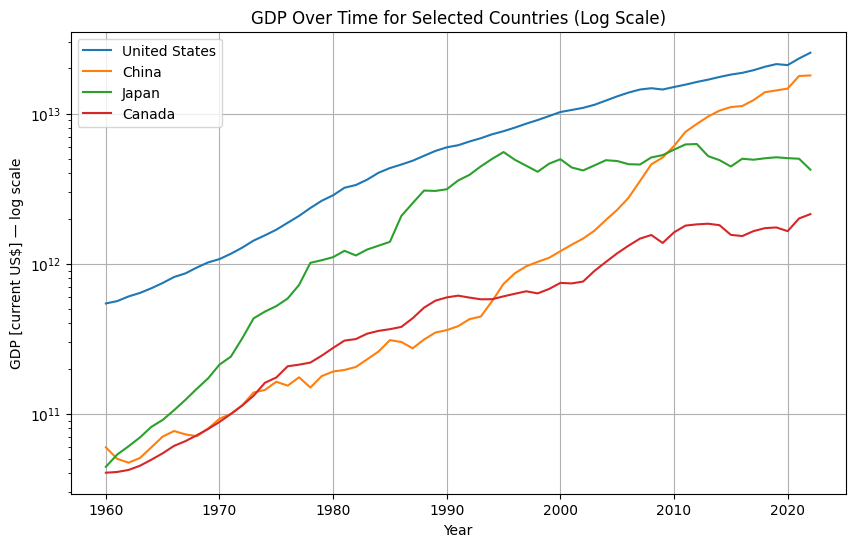

In [29]:
plt.figure(figsize=(10, 6))

for country in countries:
    if country not in gdp_transposed.columns:
        continue

    gdp_values = gdp_transposed[country].values.astype(float)
    plt.plot(years, gdp_values, label=country)

plt.yscale("log") # Set the y-axis to a logarith scale.

plt.xlabel("Year")
plt.ylabel("GDP [current US$] — log scale")
plt.title("GDP Over Time for Selected Countries (Log Scale)")

plt.legend()
plt.grid(True)
plt.show()

## 8. Correlation

Correlation measures how strongly two numerical variables are related.

A correlation close to 1 means the variables tend to increase together.

A correlation close to -1 means one variable tends to decrease as the other increases.

A correlation close to 0 means there is not a strong linear relationship.

In [30]:
selected_countries = [
    "United States",
    "China",
    "Japan",
    "Canada",
    "Australia",
    "Austria"
]

# Select only these countries from the transposed dataset
country_data = gdp_transposed[selected_countries]

# Compute correlation matrix
corr_matrix = country_data.corr()

corr_matrix

Country Name,United States,China,Japan,Canada,Australia,Austria
Country Name,,,,,,
United States,1.000000,0.901259,0.855188,0.979150,0.960732,0.976807
China,0.901259,1.000000,0.589058,0.880572,0.926767,0.833347
Japan,0.855188,0.589058,1.000000,0.851217,0.786962,0.909798
Canada,0.979150,0.880572,0.851217,1.000000,0.984920,0.984919
Australia,0.960732,0.926767,0.786962,0.984920,1.000000,0.955621
Austria,0.976807,0.833347,0.909798,0.984919,0.955621,1.000000


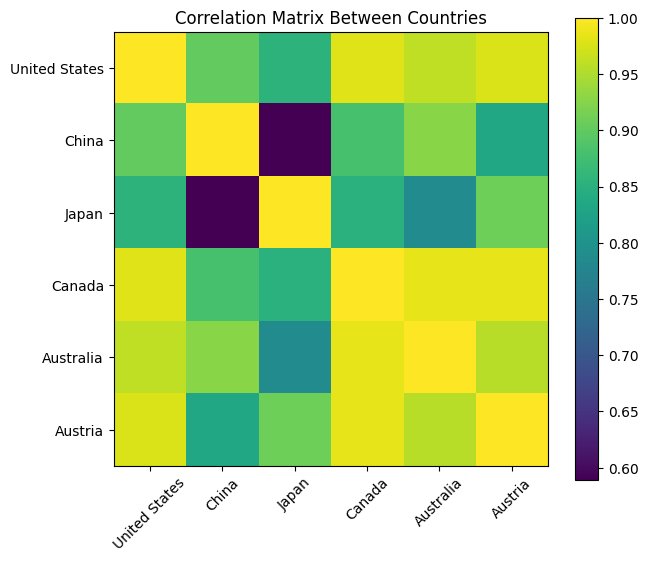

In [31]:
plt.figure(figsize=(7, 6))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(selected_countries)),
    selected_countries,
    rotation=45 # Rotate the x-axis labels by 45 degrees for better readability.
)

plt.yticks(
    range(len(selected_countries)),
    selected_countries
)

plt.title("Correlation Matrix Between Countries")

plt.show()

### Interpreting the Correlation Matrix

Countries with values closer to 1 have more similar GDP trends over time.

This does not mean the countries are identical, but it suggests their economies may grow in similar ways.

### Correlation Between All Countries

We can compute correlations for every country in the dataset.

However, with more than 100 countries, the correlation matrix becomes very difficult to interpret visually.

Even though patterns exist, it is hard to identify specific relationships directly from the heatmap.

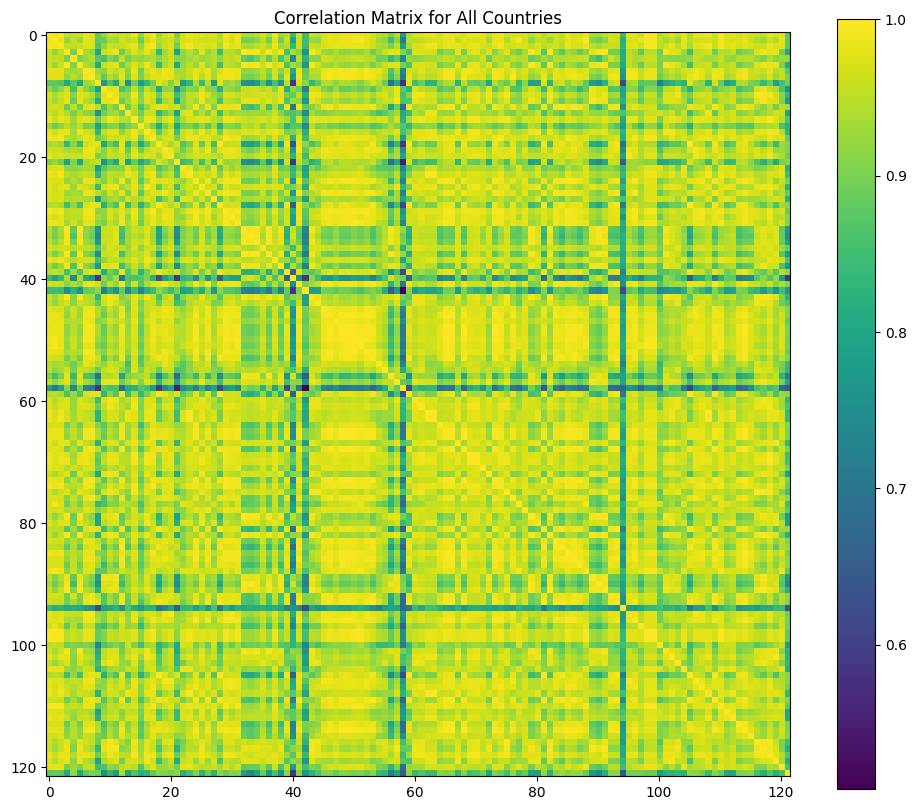

In [32]:
all_corr = gdp_transposed.corr()

plt.figure(figsize=(12,10))
plt.imshow(all_corr)

plt.colorbar()
plt.title("Correlation Matrix for All Countries")

plt.show()

### Limitation of Large Correlation Matrices

As datasets grow larger, visualization alone becomes less useful.

Instead of trying to inspect every country manually, we often use programming tools to:
- sort correlations
- filter results
- identify the strongest relationships automatically

### Finding the Most Correlated Countries

Instead of looking at every country at once, we can focus on one country and compute its correlation with all others.

Here, we will find the countries whose GDP trends are most strongly correlated with Japan.

In [35]:
country = "Burundi"

correlations = gdp_transposed.corr()[country] # Compute the correlation of the GDP data for the specified country with the GDP data of all other countries in the transposed DataFrame.

correlations = correlations.drop(country) # Drop the correlation of the country with itself.

correlations.sort_values(ascending=False) # Sort the correlations in descending order to see which countries have the highest correlation with the specified country.

Country Name
Rwanda        0.966592
Ecuador       0.965783
Honduras      0.965064
Madagascar    0.964389
IDA blend     0.963242
                ...   
Italy         0.841953
Guyana        0.822964
Sudan         0.814429
Japan         0.743035
Greece        0.742345
Name: Burundi, Length: 121, dtype: float64

## 9. Scatter Plots

We can use a scatter plot to compare the GDP of two countries over time.

Each point represents a year:
- x-axis → GDP of Country A
- y-axis → GDP of Country B

If the points follow a clear pattern, it suggests a relationship between their economies.

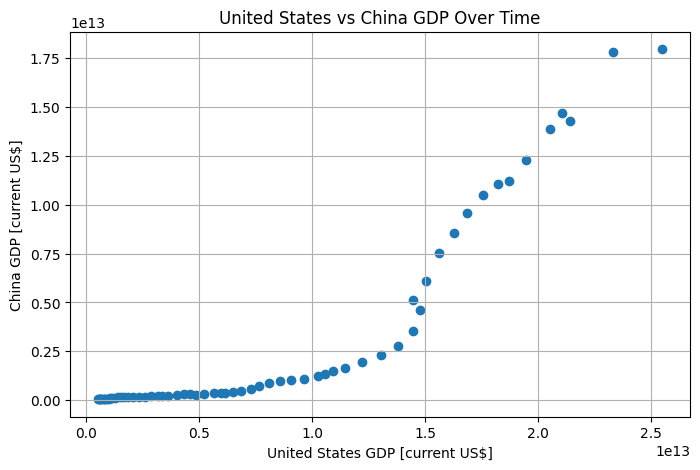

In [36]:
country1 = "United States"
country2 = "China"

gdp_1 = gdp_transposed[country1]
gdp_2 = gdp_transposed[country2]

plt.figure(figsize=(8, 5))
plt.scatter(gdp_1, gdp_2)

plt.xlabel(f"{country1} GDP [current US$]")
plt.ylabel(f"{country2} GDP [current US$]")
plt.title(f"{country1} vs {country2} GDP Over Time")

plt.grid(True)
plt.show()

### Interpretation

Each point is a year.

If the points move upward together, it means both countries’ GDPs are increasing over time.

A clear upward trend suggests a strong relationship between the two economies.

## 10. Introduction to Modeling

A model is a simplified way to describe a relationship in data.

For example, we might ask:

Can we use the year to predict GDP?

This is the basic idea behind machine learning:

Use data to learn a pattern, then use that pattern to make predictions.

In [37]:
from sklearn.linear_model import LinearRegression # Import the LinearRegression class from the linear_model module of scikit-learn, which is a machine learning library in Python. 
from sklearn.metrics import mean_squared_error, r2_score # Import the mean_squared_error and r2_score functions from the metrics module of scikit-learn, which are used to evaluate the performance of regression models.

## 11. Linear Regression

A linear regression model assumes the data follows a straight-line pattern.

In [40]:
country_name = "Burundi"

# X = years
years = gdp_transposed.index.to_numpy() # Convert index to numpy array.
X = years.reshape(-1, 1) # Reshape to make it a 2D array with one column, which is required by scikit-learn models.

# y = GDP values for selected country
y = gdp_transposed[country_name].values.astype(float) # Convert to float in case there are any non-numeric values.

linear_model = LinearRegression() # Create an instance of the LinearRegression model from scikit-learn.
linear_model.fit(X, y) # Fit the linear regression model to the data. This will find the best-fitting line that describes the relationship between the years (X) and the GDP values (y) for the specified country.

y_pred_linear = linear_model.predict(X) # Use the fitted linear model to predict the GDP values based on the years (X). This will give us the predicted GDP values according to the linear model, which we can then compare to the actual GDP values (y) to evaluate the model's performance.

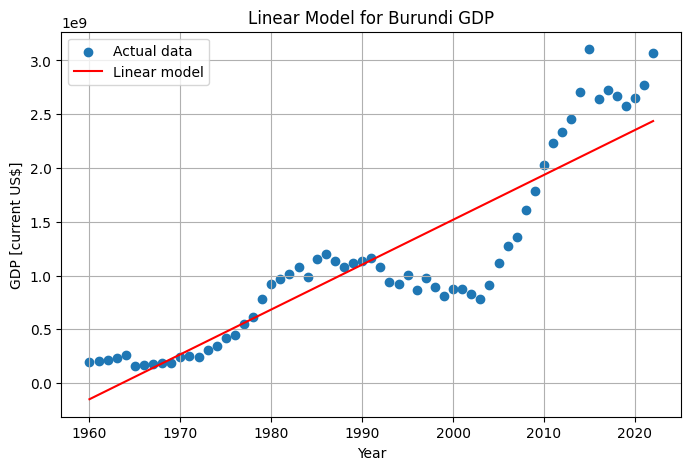

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual data")
plt.plot(X, y_pred_linear, color="red", label="Linear model")  

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Linear Model for {country_name} GDP")

plt.legend()
plt.grid(True)
plt.show()

## 12. Evaluating the Linear Model

We need to measure how well the model fits the data.

Two common metrics are:

- RMSE: average prediction error
- R²: how much variation in the data is explained by the model

In [42]:
rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear)) # Calculate the Root Mean Squared Error (RMSE) for the linear model by comparing the actual GDP values (y) with the predicted GDP values (y_pred_linear).
r2_linear = r2_score(y, y_pred_linear) # Calculate the R² score for the linear model, which is a measure of how well the model explains the variance in the data. 

print("Linear RMSE:", rmse_linear)
print("Linear R²:", r2_linear)

Linear RMSE: 378873359.64609635
Linear R²: 0.8003248986238461


## 13. Polynomial Regression

A straight line may not describe the data well.

A polynomial model can curve, so it may fit some patterns better.

In [57]:
from sklearn.preprocessing import PolynomialFeatures # Import the PolynomialFeatures class from the preprocessing module of scikit-learn, which is used to generate polynomial features from the original features. 
from sklearn.pipeline import make_pipeline # Import the make_pipeline function from the pipeline module of scikit-learn, which is used to create a pipeline that combines multiple steps (e.g., feature transformation and model fitting) into a single object that can be treated as a single estimator.

poly_model = make_pipeline( # Create a pipeline that first generates polynomial features of degree 2 from the original features (years) and then fits a linear regression model to those polynomial features.
    PolynomialFeatures(degree=3),
    LinearRegression()
)

poly_model.fit(X, y)

y_pred_poly = poly_model.predict(X)

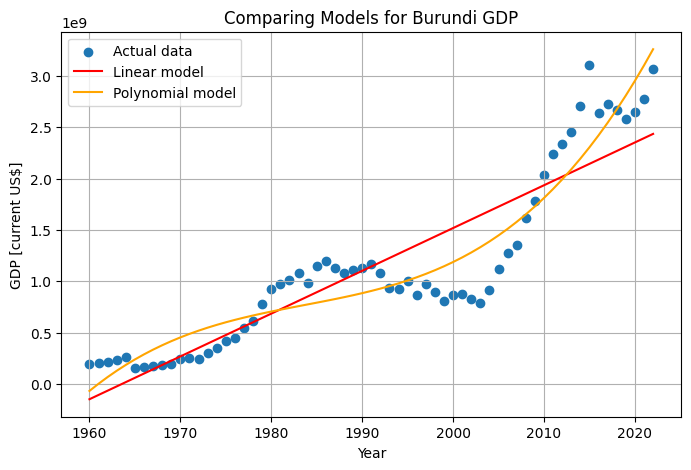

In [58]:
plt.figure(figsize=(8, 5))
plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, color="red", label="Linear model")
plt.plot(years, y_pred_poly, color="orange", label="Polynomial model")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Comparing Models for {country_name} GDP")
plt.legend()
plt.grid(True)
plt.show()

## 14. Comparing Models

Now we compare the linear model and the polynomial model using RMSE and R².

In [59]:
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
r2_poly = r2_score(y, y_pred_poly)

print("Linear RMSE:", rmse_linear)
print("Polynomial RMSE:", rmse_poly)

print("Linear R²:", r2_linear)
print("Polynomial R²:", r2_poly)

Linear RMSE: 378873359.64609635
Polynomial RMSE: 272836852.80479467
Linear R²: 0.8003248986238461
Polynomial R²: 0.8964519706877512


A lower RMSE means the model has smaller prediction errors.

A higher R² usually means the model explains more of the variation in the data.

However, a model that fits old data very well is not always better at predicting new data.

## 15. Making Predictions

Now we can use our models to predict GDP in a future year.

In [60]:
future_year = np.array([[2030]]) # Create a 2D array with the future year (2030) that we want to predict the GDP for. The shape of this array is (1, 1), which is required by scikit-learn models for making predictions.

linear_prediction = linear_model.predict(future_year)
poly_prediction = poly_model.predict(future_year)

print("Linear model prediction for 2030:", linear_prediction[0])
print("Polynomial model prediction for 2030:", poly_prediction[0])

Linear model prediction for 2030: 2769844449.6441956
Polynomial model prediction for 2030: 4810100210.71875


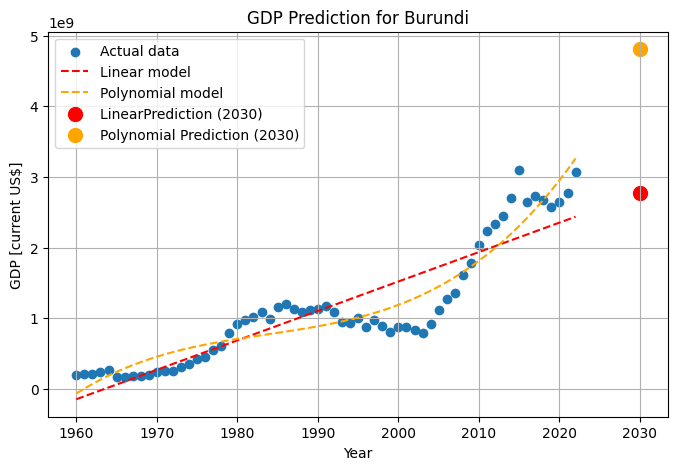

In [61]:
plt.figure(figsize=(8,5))

plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, color="red", linestyle="--", label="Linear model")
plt.plot(years, y_pred_poly, color="orange", linestyle="--", label="Polynomial model")

# Add prediction point
plt.scatter(2030, linear_prediction, color="red", s=100, label="LinearPrediction (2030)")
plt.scatter(2030, poly_prediction, color="orange", s=100, label="Polynomial Prediction (2030)")

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Prediction for {country_name}")

plt.legend()
plt.grid(True)
plt.show()

### Reflection

- Does the predicted value for 2030 follow the trend shown in the plot?
- Which model (linear or polynomial) seems more realistic? Why?
- What might happen if we try to predict too far into the future?

### Important Idea

When we predict the future using past data, we assume that:
- The same patterns will continue
- No major changes occur 

This is why predictions should always be interpreted carefully.

## 16. Training and Testing

A model can look good on the data it was trained on but perform poorly on new data.

To test this, we can train the model on earlier years and test it on later years.

In [62]:
train_mask = years <= 2010
test_mask = years > 2010

X_train = years[train_mask].reshape(-1, 1)
y_train = y[train_mask]

X_test = years[test_mask].reshape(-1, 1)
y_test = y[test_mask]

In [63]:
test_model = LinearRegression()
test_model.fit(X_train, y_train)

test_predictions = test_model.predict(X_test)

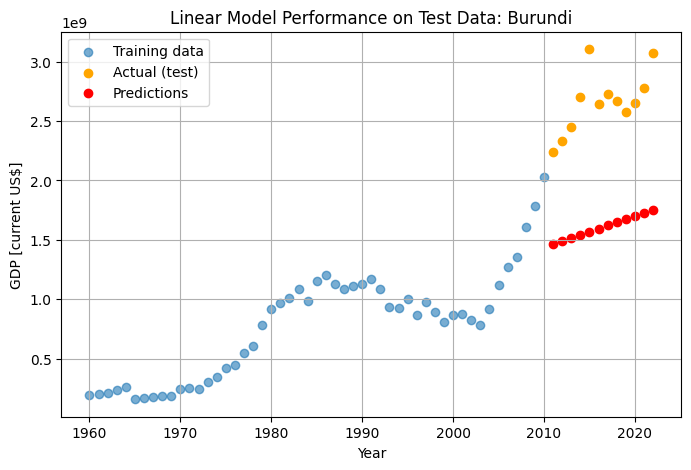

In [67]:
plt.figure(figsize=(8, 5))

# Training data
plt.scatter(X_train, y_train, label="Training data", alpha=0.6)

# Actual test data
plt.scatter(X_test, y_test, color="orange", label="Actual (test)")

# Predicted test data (as dots)
plt.scatter(X_test, test_predictions, color="red", label="Predictions")

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Linear Model Performance on Test Data: {country_name}")

plt.legend()
plt.grid(True)
plt.show()

In [68]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test RMSE: 1072795360.1532209
Test R²: -18.04943445683073


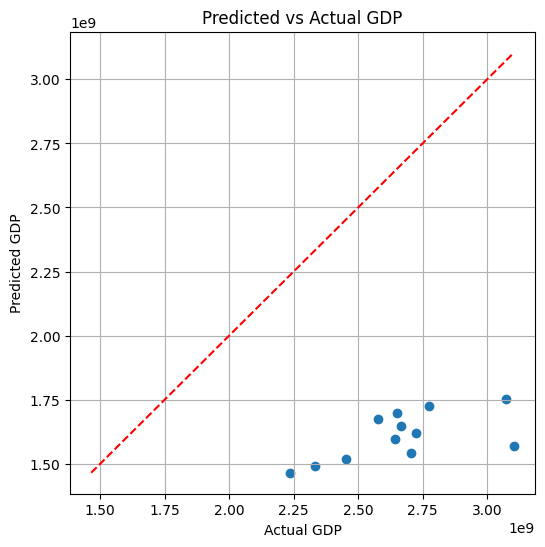

In [69]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, test_predictions)

# Perfect prediction line
min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--') # Add a dashed red line for perfect predictions

plt.xlabel("Actual GDP")
plt.ylabel("Predicted GDP")
plt.title("Predicted vs Actual GDP")

plt.grid(True)
plt.show()

This is closer to how machine learning models are evaluated.

We do not only care about how well a model fits old data.

We care about how well it predicts new data.

## 17. Your Turn: Test a Polynomial Model

In the previous section, we trained a **linear regression model** on earlier years and tested it on later years.

Now your task is to repeat the same idea, but using a **polynomial model**.

You can copy and modify code from the previous sections.

### Your goal:

1. Choose a country
2. Split the data into training years and testing years
3. Create a polynomial model
4. Fit the model using the training data
5. Predict the testing years
6. Plot:
   - training data
   - actual testing data
   - predicted testing data
7. Calculate RMSE and R²

### Questions:

1. Which country did you choose?
2. Does the polynomial model predict the test data better than the linear model?
3. Is the R² value better or worse?
4. Do you trust the polynomial model? Why or why not?

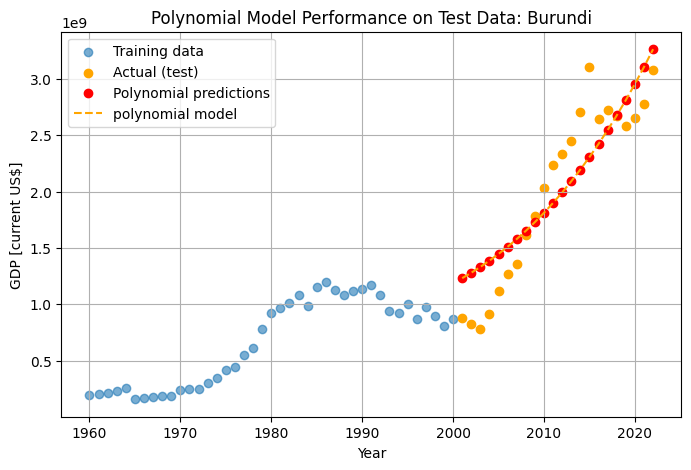

Polynomial Test RMSE: 353721550.4663828
Polynomial Test R²: 0.7912249945109955


In [75]:
# Choose a country
chosen_country = "Burundi"

# Get years and GDP values
years = gdp_transposed.index.to_numpy()
y = gdp_transposed[chosen_country].values.astype(float)

# Create training and testing masks
train_mask = years <= 2000
test_mask = years > 2000

# Create X and y training/testing data
X_train = years[train_mask].reshape(-1, 1)
y_train = y[train_mask]

X_test = years[test_mask].reshape(-1, 1)
y_test = y[test_mask]

# Create a polynomial model
# Hint: use make_pipeline(), PolynomialFeatures(), and LinearRegression()
poly_test_model = make_pipeline( # Create a pipeline that first generates polynomial features of degree 2 from the original features (years) and then fits a linear regression model to those polynomial features.
    PolynomialFeatures(degree=3),
    LinearRegression()
)

# Fit the model

poly_test_model.fit(X, y)

# Predict the testing data
poly_test_predictions = poly_model.predict(X_test)

# Plot training, actual testing, and predicted testing data
plt.figure(figsize=(8, 5))

# Uncomment and fill in the code below to plot the training data, actual test data, and polynomial predictions on the same graph for comparison.
plt.scatter(X_train, y_train, label="Training data", alpha=0.6)
plt.scatter(X_test, y_test, color="orange", label="Actual (test)")
plt.scatter(X_test, poly_test_predictions, color="red", label="Polynomial predictions")

plt.plot(X_test, poly_test_predictions, color="orange", linestyle="--", label="polynomial model")

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Polynomial Model Performance on Test Data: {chosen_country}")

plt.legend()
plt.grid(True)
plt.show()

# Evaluate the model
poly_test_rmse = np.sqrt(mean_squared_error(y_test, poly_test_predictions))
poly_test_r2 = r2_score(y_test, poly_test_predictions)

print("Polynomial Test RMSE:", poly_test_rmse)
print("Polynomial Test R²:", poly_test_r2)

In [ ]:
# Hint for creating the polynomial model:
# poly_test_model = make_pipeline(
#     PolynomialFeatures(degree=2),
#     LinearRegression()
# )

## 18. Optional: Introduction to SVD

Singular Value Decomposition, or SVD, is a method that breaks a dataset into important patterns.

It is often used for:
- Dimensionality reduction
- Compression
- Finding hidden patterns in data
- Preparing data for machine learning

Here, we will apply SVD to the GDP dataset to see if a few patterns can represent most of the data.

In [76]:
# Select only the numerical GDP values
# Rows = years, columns = countries
gdp_matrix = gdp_transposed.values.astype(float)

# Scale the data so very large countries do not dominate too much
gdp_matrix_scaled = (gdp_matrix - gdp_matrix.mean(axis=0)) / gdp_matrix.std(axis=0)

# Replace possible NaN values caused by zero standard deviation
gdp_matrix_scaled = np.nan_to_num(gdp_matrix_scaled)

SVD separates the data matrix into three parts:

\[
X = U \Sigma V^T
\]

The most important values are the singular values. Larger singular values represent stronger patterns in the data.

In [77]:
U, S, Vt = np.linalg.svd(gdp_matrix_scaled, full_matrices=False)

S

array([8.49134311e+01, 1.61454558e+01, 8.97364750e+00, 5.45528193e+00,
       5.10596509e+00, 4.25321508e+00, 3.76996521e+00, 3.34932526e+00,
       2.36483023e+00, 2.07106044e+00, 2.01816994e+00, 1.80909291e+00,
       1.65960458e+00, 1.60502977e+00, 1.42106210e+00, 1.19719982e+00,
       1.13763179e+00, 1.07787849e+00, 9.68493047e-01, 8.80619432e-01,
       7.90455802e-01, 7.46090338e-01, 6.79192286e-01, 6.55811143e-01,
       5.88981157e-01, 5.72112488e-01, 5.49480660e-01, 4.90568764e-01,
       4.73169603e-01, 4.45146550e-01, 4.15519145e-01, 3.84186627e-01,
       3.68106867e-01, 3.34423138e-01, 3.19592923e-01, 2.98983120e-01,
       2.85037155e-01, 2.79972793e-01, 2.65521198e-01, 2.25927317e-01,
       2.08155893e-01, 1.92655438e-01, 1.79541115e-01, 1.59424927e-01,
       1.38181152e-01, 1.23035392e-01, 1.20423579e-01, 1.02035253e-01,
       8.69343886e-02, 7.63921724e-02, 5.68581113e-02, 5.21916891e-02,
       4.97886385e-02, 3.64990697e-02, 3.24308115e-02, 2.73067969e-02,
      

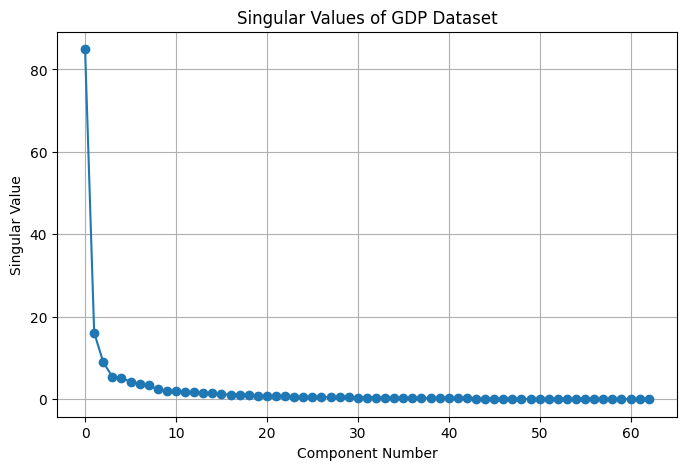

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(S, marker="o")

plt.xlabel("Component Number")
plt.ylabel("Singular Value")
plt.title("Singular Values of GDP Dataset")

plt.grid(True)
plt.show()

### Interpreting the Plot

If the first few singular values are much larger than the rest, then a small number of patterns explain most of the dataset.

This is useful because it means we may not need every original variable to understand the main structure of the data.

In [79]:
# Keep only the first k patterns
k = 5

U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

gdp_approx = U_k @ S_k @ Vt_k

The reconstructed dataset `gdp_approx` is an approximation of the original data using only the first few SVD components.

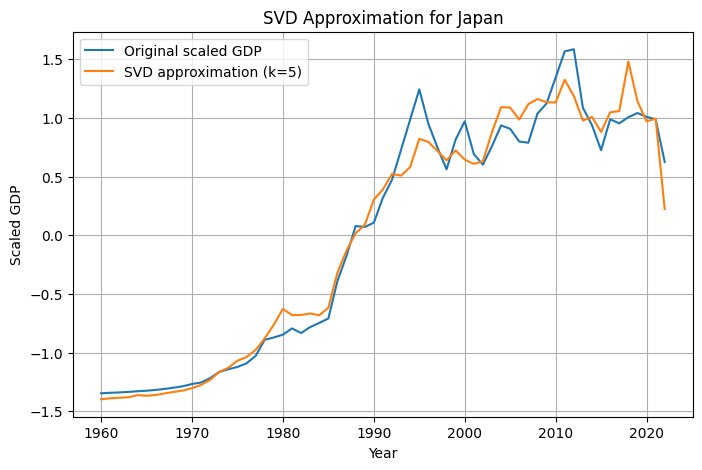

In [80]:
country = "Japan"

country_index = list(gdp_transposed.columns).index(country)

original = gdp_matrix_scaled[:, country_index]
approx = gdp_approx[:, country_index]

plt.figure(figsize=(8, 5))

plt.plot(gdp_transposed.index, original, label="Original scaled GDP")
plt.plot(gdp_transposed.index, approx, label=f"SVD approximation (k={k})")

plt.xlabel("Year")
plt.ylabel("Scaled GDP")
plt.title(f"SVD Approximation for {country}")

plt.legend()
plt.grid(True)
plt.show()

### Key Idea

SVD helps us summarize a large dataset using fewer patterns.

This connects to machine learning because many ML methods work better when data is simplified, compressed, or transformed into more meaningful features.

## Final Reflection

In this notebook, we practiced the basic workflow used in data analysis and machine learning:

1. Load data
2. Inspect data
3. Clean missing values
4. Visualize patterns
5. Look for relationships
6. Filter useful subsets
7. Fit a model
8. Evaluate the model
9. Make predictions
10. Question whether the predictions make sense
11. Introduction to SVD

This workflow is the foundation for more advanced machine learning.